In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [3]:
DATA_DIR = Path(r"D:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"D:\lab\cptac_prostate\runs\20260330_cptac_ubi_tmt_sample_issues")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [4]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [5]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [6]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [9]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [13]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"ubi_TMT_ratio",i.stem, re.IGNORECASE) and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
header_cols = ["gene_site","Index","SequenceWindow"]
data = pd.read_csv(data_path,sep="\t").set_index(header_cols)
data_nomiss = data.dropna()

In [14]:
data

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.08371.N,C3L.07465.T,C3L.09972.T,C3N.08952.T,C3N.08880.T,C3L.07606.N,C3L.07861.T,C3L.07606.T,C3L.07292.N,CHTN.49141.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
ARF5_K142,ENSP00000000233_K142,PVSELTDkLGLQHLR,NaN,NaN,NaN,NaN,0.402468,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ARF5_K73,ENSP00000000233_K73,WDVGGQDkIRPLWRH,1.532097,-0.119403,0.098666,-0.252600,-0.183762,0.332808,-0.722082,-0.034021,-0.589605,-0.112418,...,-0.689048,0.116697,0.106626,0.325935,0.190788,-1.355962,-0.117618,-0.533808,-0.520944,-1.608762
FKBP4_K179,ENSP00000001008_K179,VALEGYYkDKLFDQR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_K222,ENSP00000001008_K222,EHSIVYLkPSYAFGS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_K250,ENSP00000001008_K250,LKYELHLkSFEKAKE,-1.036623,-0.244788,-0.204607,-0.428873,0.232416,0.165417,-0.329974,-0.882156,0.278785,-0.257209,...,0.074793,-0.377876,0.062219,-0.006570,0.367416,0.409014,-0.063714,0.612627,0.216953,0.004498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EPB41L2_K695,ENSP00000516350_K695,FKDILSVkEKYLMPT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPB41L2_K83,ENSP00000516350_K83,RFIPPWLkKQKSYTL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPB41L2_K86,ENSP00000516350_K86,PPWLKKQkSYTLVVA,-0.736009,-0.792549,-0.983064,-0.576150,-0.311279,-0.675135,-0.064949,0.117368,-0.769245,0.012084,...,0.602494,-0.105598,0.941922,0.108946,0.393263,0.029734,-0.119493,0.268983,0.032642,0.395729


In [15]:
data_nomiss

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.08371.N,C3L.07465.T,C3L.09972.T,C3N.08952.T,C3N.08880.T,C3L.07606.N,C3L.07861.T,C3L.07606.T,C3L.07292.N,CHTN.49141.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
BAIAP2L1_K279,ENSP00000005260_K279,KDYDTLSkCSPKMPP,1.249167,-0.757687,0.331505,0.247987,0.091506,-0.984783,0.761747,0.018729,-1.394850,-0.495487,...,0.292600,-0.901060,-0.703619,-0.484016,-1.068045,-0.522856,-1.138157,-0.994654,-0.809111,-0.604100
RPS20_K30,ENSP00000009589_K30,TLTSRNVkSLEKVCA,0.495688,-0.525935,-0.679898,0.370659,0.632420,-0.757156,0.295591,-0.507033,0.321027,-0.435678,...,0.761752,-0.003989,-0.543347,-0.391744,-0.394004,0.046302,-0.306116,-0.504787,-0.839142,-0.749409
RPS20_K34,ENSP00000009589_K34,RNVKSLEkVCADLIR,0.071532,-0.321470,0.711634,0.142783,-0.642919,0.503261,-0.659277,0.011270,-0.320110,-0.193164,...,0.108265,-0.327224,0.214371,-1.171349,-0.219757,0.281876,-0.206765,-0.353703,-0.198535,-1.565887
RPS20_K8,ENSP00000009589_K8,MAFKDTGkTPVEPEV,0.230661,0.228702,-1.066245,0.740088,0.741800,-0.375151,0.973612,-0.833959,-1.270654,-0.747110,...,0.224634,-0.864423,-0.719431,-0.755494,-1.300542,-0.097704,-0.974114,-1.343285,-1.309047,-1.032418
RTF2_K122,ENSP00000023939_K122,IKNVTELkLSDNPAW,-0.189754,-0.667366,0.865966,-0.869042,-1.119579,0.280485,-0.247879,1.311822,0.647454,0.551585,...,-1.255461,1.010425,1.002674,1.101739,1.266526,-0.565574,1.200829,1.153749,0.793904,0.123098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EPB41L2_K270,ENSP00000516350_K270,FQESPEQkNWLDPAK,0.096019,-0.053565,-0.137337,0.257652,-0.131630,0.140285,0.108434,-1.325826,-0.012452,-0.035940,...,0.163404,-0.310110,-0.172418,-0.405939,-0.064256,0.527518,-0.374347,-0.193463,0.201426,-0.227602
EPB41L2_K374,ENSP00000516350_K374,QTKELEEkVAELHKT,0.155735,0.135034,-0.179189,0.098494,-0.395692,-0.313864,0.209039,-0.409315,-0.554360,-0.593986,...,-0.107340,-0.577948,-0.196011,-0.596211,-0.406463,0.497609,-0.403987,-0.630055,-0.685793,-0.653306
EPB41L2_K399,ENSP00000516350_K399,SQFLENAkRLSMYGV,0.393942,0.783797,0.482179,0.536852,0.181073,0.397125,0.891389,0.487043,0.413670,0.951778,...,0.198906,-0.191775,-0.062978,-0.071399,0.085953,0.699732,-0.132209,-0.115764,-0.278468,0.514209


In [16]:
samples = data.columns.tolist()
len(samples)

171

In [17]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 171)


In [18]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Figure size 800x800 with 0 Axes>

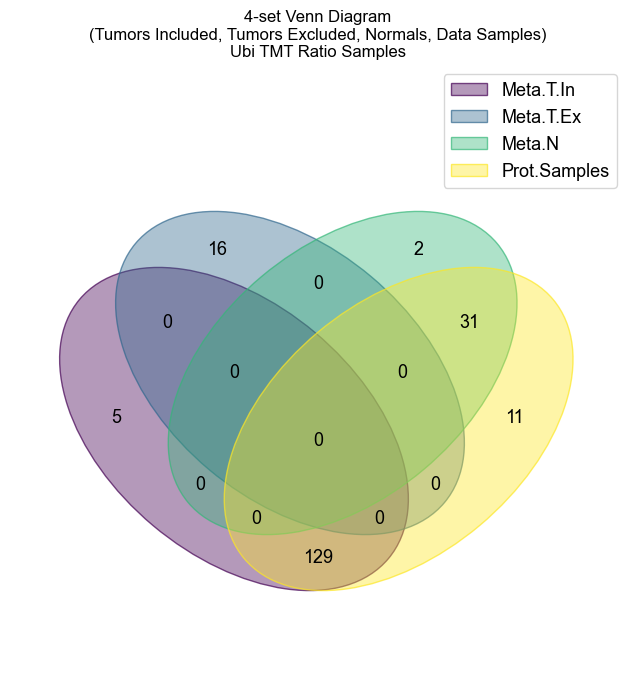

In [20]:
import matplotlib.pyplot as plt
from venn import venn

# 四个集合
sets = {
    "Meta.T.In": set_tumors_included,
    "Meta.T.Ex": set_tumors_excluded,
    "Meta.N": set_normals,
    "Prot.Samples": set_data
}

plt.figure(figsize=(8, 8))
venn(sets)
plt.title("4-set Venn Diagram\n(Tumors Included, Tumors Excluded, Normals, Data Samples)\nUbi TMT Ratio Samples")
plt.show()